<a href="https://colab.research.google.com/github/jane-disciullo/sp500-backtesting-strategy/blob/main/02_parameter_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
!git pull

Already up to date.


# Part 1: Parameter Testing Overview

This notebook tests how the performance of a moving-average strategy changes across different ma windows using historical SPY data. I compared 20, 50, 100, 150, 200, and 250-day moving averages against a buy-and-hold SPY benchmark. The goal is to evaluate parameter sensitivity and determine whether performance depends heavily on the chosen moving-average window.

This notebook was developed with assistance from AI tools for debugging, troubleshooting, and syntax correction.

In [36]:
import importlib
import src.data

importlib.reload(src.data)

from src.data import load_spy_data

In [37]:
price = load_spy_data(
    start="2015-01-01",
    end="2026-01-01"
)

print(price.columns.tolist())

/content/sp500-backtesting-strategy/src/data.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  end=end,
[*********************100%***********************]  1 of 1 completed

['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'Daily_Return', 'Bench_Bal']


In [38]:
test_price = generate_ma_signal(price, ma=50)

test_result = run_backtest(
    test_price,
    starting_balance=100_000
)

test_metrics = calculate_total_return(test_result)

print(test_metrics)

{'final_bench': np.float64(399742.964965307), 'final_strategy': np.float64(213152.6105712086), 'bench_total_return': np.float64(2.99742964965307), 'sys_total_return': np.float64(1.1315261057120862)}


In [39]:
!git pull

Already up to date.


In [40]:
import importlib
import src.backtest

importlib.reload(src.backtest)

from src.backtest import run_backtest

In [41]:
!cat -n src/backtest.py


     1	import numpy as np
     2	
     3	
     4	def run_backtest(price, starting_balance=100_000):
     5	    """
     6	    Run the moving-average strategy backtest.
     7	
     8	    Parameters:
     9	        price (pandas.DataFrame): Price data containing
    10	            'Long' and 'Return' columns.
    11	        starting_balance (float): Initial portfolio balance.
    12	
    13	    Returns:
    14	        pandas.DataFrame: Price data with strategy returns
    15	        and strategy balance.
    16	    """
    17	
    18	    price = price.copy()
    19	
    20	    price["Sys_Ret"] = np.where(
    21	        price["Long"].shift(1) == True,
    22	        1 + price["Return"],
    23	        1
    24	    )
    25	
    26	    price["Sys_Bal"] = (
    27	        starting_balance * price["Sys_Ret"].cumprod()
    28	    )
    29	
    30	    return price


In [42]:
!git pull

Already up to date.


In [43]:
import importlib
import src.backtest

importlib.reload(src.backtest)

from src.backtest import run_backtest

In [44]:
test_price = generate_ma_signal(price, ma=50)

test_result = run_backtest(
    test_price,
    starting_balance=100_000
)

test_metrics = calculate_total_return(test_result)

print(test_metrics)

{'final_bench': np.float64(399742.964965307), 'final_strategy': np.float64(213152.6105712086), 'bench_total_return': np.float64(2.99742964965307), 'sys_total_return': np.float64(1.1315261057120862)}


In [49]:
print("Starting parameter test...")

ma_values = [20, 50, 100, 150, 200, 250]

results = []

for ma in ma_values:
    print(f"Testing MA = {ma}")

    test_price = generate_ma_signal(price, ma=ma)

    test_result = run_backtest(
        test_price,
        starting_balance=100_000
    )

    metrics = calculate_total_return(test_result)

    results.append({
        "MA": ma,
        "Strategy Return": metrics["sys_total_return"],
        "Final Strategy Balance": metrics["final_strategy"],
        "Benchmark Return": metrics["bench_total_return"],
        "Final Benchmark Balance": metrics["final_bench"],
    })

print("Finished!")

Starting parameter test...
Testing MA = 20
Testing MA = 50
Testing MA = 100
Testing MA = 150
Testing MA = 200
Testing MA = 250
Finished!


# Part 2: Parameter Results

In [50]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,MA,Strategy Return,Final Strategy Balance,Benchmark Return,Final Benchmark Balance
0,20,1.170678,217067.819542,2.99743,399742.964965
1,50,1.131526,213152.610571,2.99743,399742.964965
2,100,1.540820,254081.976138,2.99743,399742.964965
3,150,1.560118,256011.783179,2.99743,399742.964965
4,200,1.886776,288677.578424,2.99743,399742.964965
5,250,1.778920,277892.030964,2.99743,399742.964965


In [51]:
results_df.sort_values(
    "Strategy Return",
    ascending=False
)

,MA,Strategy Return,Final Strategy Balance,Benchmark Return,Final Benchmark Balance
4,200,1.886776,288677.578424,2.99743,399742.964965
5,250,1.778920,277892.030964,2.99743,399742.964965
3,150,1.560118,256011.783179,2.99743,399742.964965
2,100,1.540820,254081.976138,2.99743,399742.964965
0,20,1.170678,217067.819542,2.99743,399742.964965
1,50,1.131526,213152.610571,2.99743,399742.964965


# Part 3: Out of Sample Testing

In [52]:
train = price.loc["2015-01-01":"2022-12-31"].copy()
test = price.loc["2023-01-01":"2026-01-01"].copy()

print("In-sample:", train.index.min(), "to", train.index.max())
print("Out-of-sample:", test.index.min(), "to", test.index.max())

In-sample: 2015-01-02 00:00:00 to 2022-12-30 00:00:00
Out-of-sample: 2023-01-03 00:00:00 to 2025-12-31 00:00:00


# Part 4: In-Sample Parameter Selection

The moving-average parameters are evaluated using only the 2015–2022 in-sample period. The best-performing parameter will be tested on the separate 2023-2025 out of sample period.


In [53]:
ma_values = [20, 50, 100, 150, 200, 250]

train_results = []

for ma in ma_values:
    train_test = train.copy()

    # Recalculate benchmark balance from the start of the training period
    train_test["Bench_Bal"] = (
        100_000 * (1 + train_test["Daily_Return"]).cumprod()
    )

    train_test = generate_ma_signal(train_test, ma=ma)

    backtest = run_backtest(
        train_test,
        starting_balance=100_000
    )

    metrics = calculate_total_return(backtest)

    train_results.append({
        "MA": ma,
        "Strategy Return": metrics["sys_total_return"],
        "Final Strategy Balance": metrics["final_strategy"]
    })

train_results_df = pd.DataFrame(train_results)

train_results_df.sort_values(
    "Strategy Return",
    ascending=False
)

,MA,Strategy Return,Final Strategy Balance
5,250,0.864113,186411.324400
4,200,0.792143,179214.349548
0,20,0.536183,153618.345757
2,100,0.526944,152694.350548
3,150,0.514857,151485.689894
1,50,0.352555,135255.472779


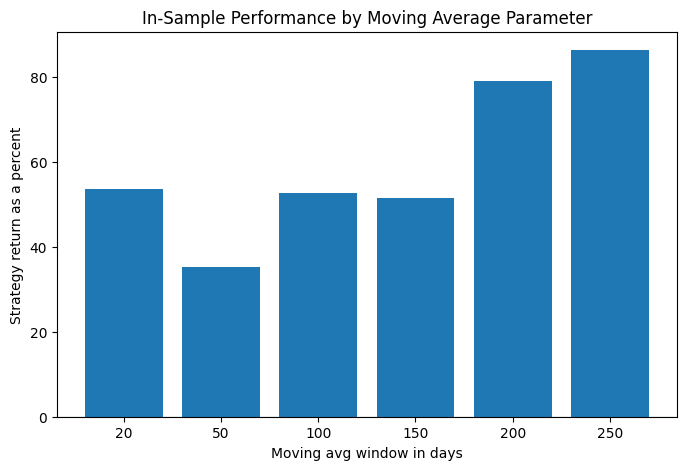

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    train_results_df["MA"].astype(str),
    train_results_df["Strategy Return"] * 100
)

plt.xlabel("Moving avg window in days")
plt.ylabel("Strategy return as a percent")
plt.title("In-Sample Performance by Moving Average Parameter")
plt.axhline(0, linewidth=0.8)

plt.show()

In [54]:
best_ma = 250

test_oos = test.copy()

# Recalculate benchmark from $100,000 at the start of the test period
test_oos["Bench_Bal"] = (
    100_000 * (1 + test_oos["Daily_Return"]).cumprod()
)

test_oos = generate_ma_signal(
    test_oos,
    ma=best_ma
)

oos_result = run_backtest(
    test_oos,
    starting_balance=100_000
)

oos_metrics = calculate_total_return(oos_result)

print(oos_metrics)

{'final_bench': np.float64(185497.56283932072), 'final_strategy': np.float64(133282.4904603061), 'bench_total_return': np.float64(0.8549756283932071), 'sys_total_return': np.float64(0.3328249046030609)}


In [55]:
print(f"250-day MA return: {oos_metrics['sys_total_return']:.2%}")
print(f"SPY buy-and-hold return: {oos_metrics['bench_total_return']:.2%}")

250-day MA return: 33.28%
SPY buy-and-hold return: 85.50%


# Part 5: Risk Analysis

In [60]:
from src.metrics import (
    calculate_total_return,
    calculate_sharpe_ratio,
    calculate_cagr,
    calculate_max_drawdown,
)

In [61]:
years = (
    (oos_result.index[-1] - oos_result.index[0]).days / 365.25
)

sharpe = calculate_sharpe_ratio(oos_result)
cagr = calculate_cagr(oos_result, years)
drawdown = calculate_max_drawdown(oos_result)

print("CAGR")
print(f"Strategy: {cagr['cagr_strategy']:.2%}")
print(f"SPY:      {cagr['cagr_bench']:.2%}")

print("\nSharpe Ratio")
print(f"Strategy: {sharpe['strategy_sharpe']:.2f}")
print(f"SPY:      {sharpe['bench_sharpe']:.2f}")

print("\nMaximum Drawdown")
print(f"Strategy: {drawdown['dd_strategy']:.2f}%")
print(f"SPY:      {drawdown['dd_bench']:.2f}%")

CAGR
Strategy: 10.08%
SPY:      23.11%

Sharpe Ratio
Strategy: 0.97
SPY:      1.43

Maximum Drawdown
Strategy: -16.28%
SPY:      -18.76%
